In [1]:
import sys
sys.path.append(r'C:\Users\ASUS\Documents\DDM')

from ddm_core import simulate_ddm, fit_ddm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# STUDY DESIGN — fixed before running anything
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}

sample_sizes = [50, 100, 200, 500]   # trials per simulation
n_simulations = 50                   # start with 10, change to 50 for final run

print("Study design:")
print(f"True parameters: {true_params}")
print(f"Sample sizes: {sample_sizes}")
print(f"Simulations per condition: {n_simulations}")
print(f"Total fits to run: {len(sample_sizes) * n_simulations}")

Study design:
True parameters: {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
Sample sizes: [50, 100, 200, 500]
Simulations per condition: 50
Total fits to run: 200


In [3]:
results = []

for n in sample_sizes:
    for sim in range(n_simulations):
        # Simulate data from true parameters
        data = simulate_ddm(**true_params, n_trials=n)
        
        # Fit model and recover parameters
        estimated = fit_ddm(data)
        
        # Store true vs estimated
        results.append({
            'n_trials': n,
            'sim': sim,
            'true_v':  true_params['v'],  'est_v':  estimated['v'],
            'true_a':  true_params['a'],  'est_a':  estimated['a'],
            'true_z':  true_params['z'],  'est_z':  estimated['z'],
            'true_t0': true_params['t0'], 'est_t0': estimated['t0'],
        })
        
        # Print progress after every fit
        print(f"n={n}, sim={sim+1}/{n_simulations} | "
              f"v={estimated['v']:.3f} "
              f"a={estimated['a']:.3f} "
              f"z={estimated['z']:.3f} "
              f"t0={estimated['t0']:.3f}")

# Save immediately
df = pd.DataFrame(results)
df.to_csv('recovery_results.csv', index=False)
print(f"\nDone. Results saved to recovery_results.csv")

n=50, sim=1/50 | v=0.096 a=1.209 z=0.347 t0=0.187
n=50, sim=2/50 | v=0.575 a=1.336 z=0.545 t0=0.153
n=50, sim=3/50 | v=-0.053 a=1.010 z=0.386 t0=0.233
n=50, sim=4/50 | v=0.263 a=1.205 z=0.499 t0=0.151
n=50, sim=5/50 | v=0.812 a=1.120 z=0.537 t0=0.171
n=50, sim=6/50 | v=0.241 a=1.136 z=0.528 t0=0.158
n=50, sim=7/50 | v=0.697 a=0.941 z=0.571 t0=0.183
n=50, sim=8/50 | v=0.068 a=1.141 z=0.539 t0=0.154
n=50, sim=9/50 | v=0.139 a=1.028 z=0.578 t0=0.195
n=50, sim=10/50 | v=0.556 a=1.088 z=0.550 t0=0.164
n=50, sim=11/50 | v=-0.270 a=1.277 z=0.376 t0=0.182
n=50, sim=12/50 | v=0.235 a=1.213 z=0.357 t0=0.208
n=50, sim=13/50 | v=0.281 a=1.271 z=0.509 t0=0.125
n=50, sim=14/50 | v=0.129 a=1.013 z=0.434 t0=0.203
n=50, sim=15/50 | v=0.116 a=1.210 z=0.516 t0=0.144
n=50, sim=16/50 | v=0.628 a=1.209 z=0.545 t0=0.162
n=50, sim=17/50 | v=0.663 a=1.221 z=0.519 t0=0.144
n=50, sim=18/50 | v=0.397 a=1.211 z=0.541 t0=0.157
n=50, sim=19/50 | v=0.278 a=1.177 z=0.502 t0=0.152
n=50, sim=20/50 | v=0.586 a=1.183 z=0.

In [4]:
df = pd.read_csv('recovery_results.csv')

print("Mean estimated parameters by sample size:")
print("=" * 55)
print(f"{'n':>6} | {'v (0.30)':>10} | {'a (1.20)':>10} | {'z (0.50)':>10} | {'t0 (0.15)':>10}")
print("-" * 55)

for n in sample_sizes:
    subset = df[df['n_trials'] == n]
    print(f"{n:>6} | "
          f"{subset['est_v'].mean():>10.3f} | "
          f"{subset['est_a'].mean():>10.3f} | "
          f"{subset['est_z'].mean():>10.3f} | "
          f"{subset['est_t0'].mean():>10.3f}")

Mean estimated parameters by sample size:
     n |   v (0.30) |   a (1.20) |   z (0.50) |  t0 (0.15)
-------------------------------------------------------
    50 |      0.279 |      1.184 |      0.491 |      0.168
   100 |      0.242 |      1.209 |      0.487 |      0.162
   200 |      0.293 |      1.227 |      0.489 |      0.157
   500 |      0.327 |      1.237 |      0.504 |      0.151


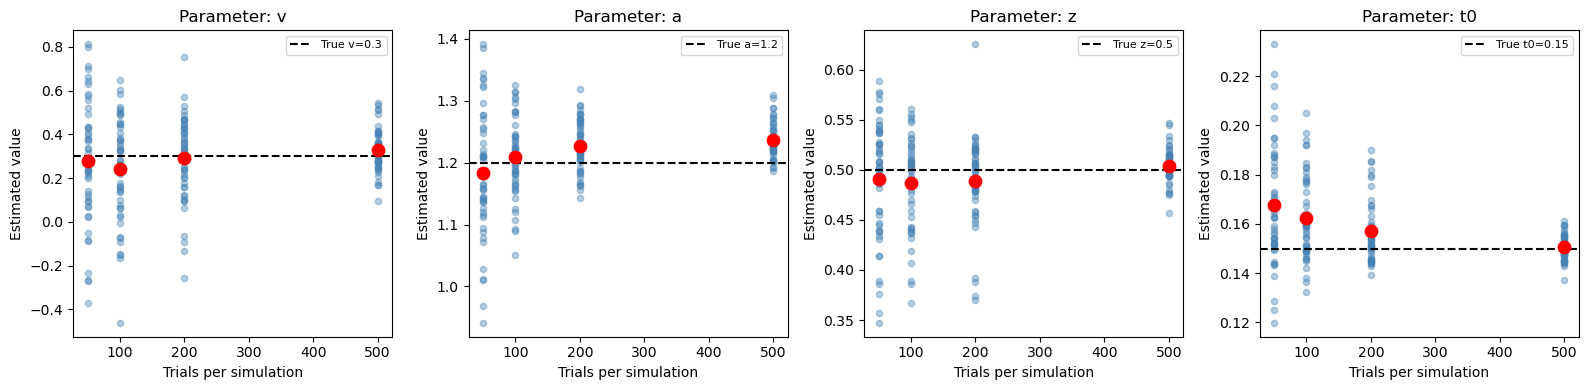

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = ['v', 'a', 'z', 't0']
true_vals = [0.3, 1.2, 0.5, 0.15]

for i, (param, true_val) in enumerate(zip(params, true_vals)):
    ax = axes[i]
    for n in sample_sizes:
        subset = df[df['n_trials'] == n]
        estimates = subset[f'est_{param}']
        ax.scatter([n] * len(estimates), estimates, 
                  alpha=0.4, s=20, color='steelblue')
        ax.scatter(n, estimates.mean(), 
                  s=80, color='red', zorder=5)
    
    ax.axhline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {param}={true_val}')
    ax.set_xlabel('Trials per simulation')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'Parameter: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('recovery_plot.png', dpi=150)
plt.show()

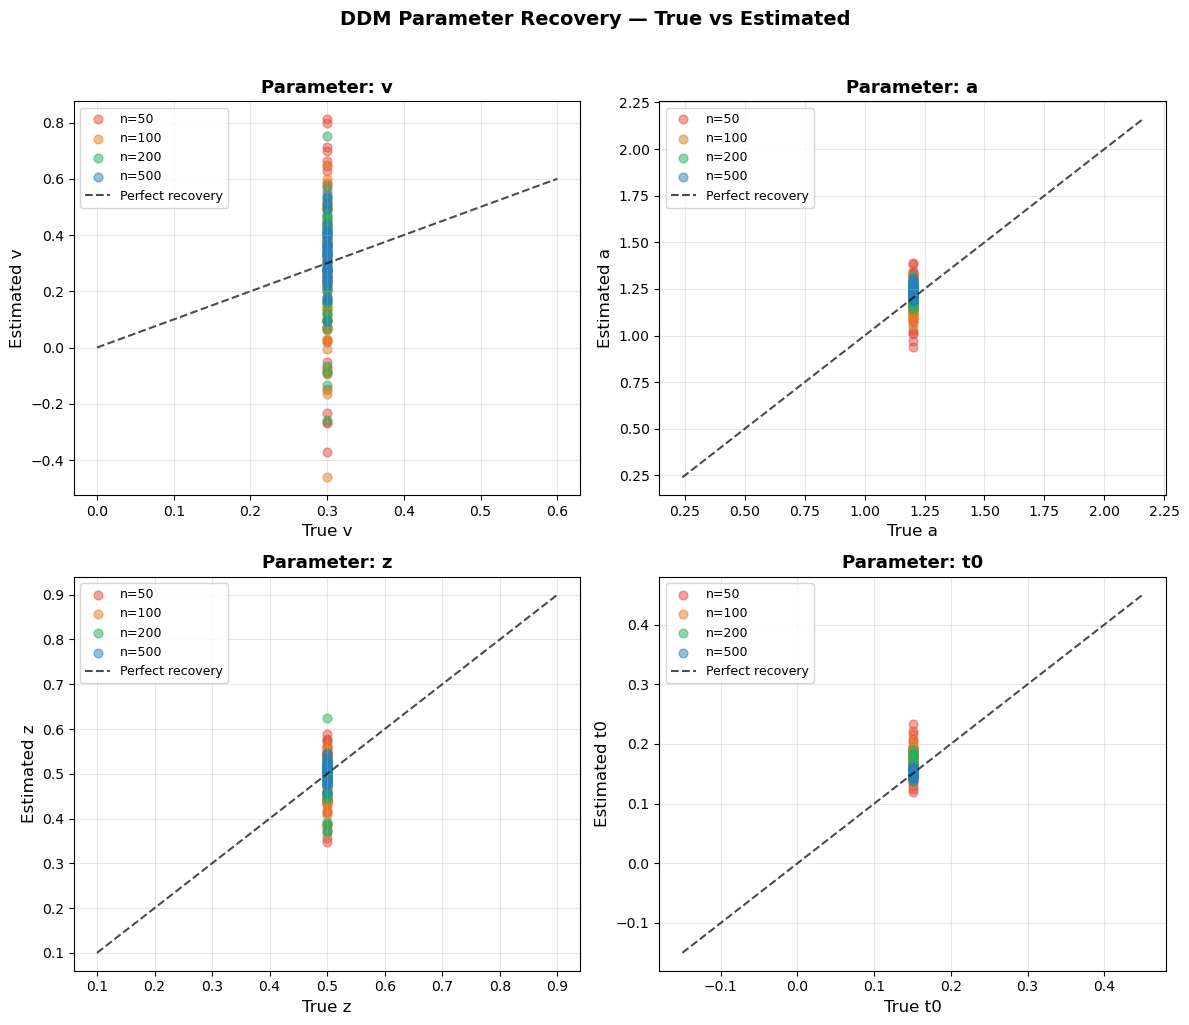

Figure saved as recovery_scatter.png


In [6]:
df = pd.read_csv('recovery_results.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
colors = {50: '#e74c3c', 100: '#e67e22', 200: '#27ae60', 500: '#2980b9'}
labels = {50: 'n=50', 100: 'n=100', 200: 'n=200', 500: 'n=500'}

for idx, param in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    for n in [50, 100, 200, 500]:
        subset = df[df['n_trials'] == n]
        ax.scatter(
            subset[f'true_{param}'],
            subset[f'est_{param}'],
            alpha=0.5, s=40,
            color=colors[n],
            label=labels[n]
        )
    
    # Perfect recovery diagonal
    true_val = true_vals[param]
    spread = max(0.3, abs(true_val) * 0.8)
    lims = [true_val - spread, true_val + spread]
    ax.plot(lims, lims, 'k--', linewidth=1.5, 
            alpha=0.7, label='Perfect recovery')
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Estimated {param}', fontsize=12)
    ax.set_title(f'Parameter: {param}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DDM Parameter Recovery — True vs Estimated', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recovery_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recovery_scatter.png")

In [7]:
# STUDY DESIGN 
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}

sample_sizes = [50, 100, 200, 500]   # trials per simulation
n_simulations_02 = 500                   

print("Study design:")
print(f"True parameters: {true_params}")
print(f"Sample sizes: {sample_sizes}")
print(f"Simulations per condition: {n_simulations_02}")
print(f"Total fits to run: {len(sample_sizes) * n_simulations_02}")

Study design:
True parameters: {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
Sample sizes: [50, 100, 200, 500]
Simulations per condition: 500
Total fits to run: 2000


In [8]:
results_500 = []

for n in sample_sizes:
    for sim in range(n_simulations_02):
        # Simulate data from true parameters
        data = simulate_ddm(**true_params, n_trials=n)
        
        # Fit model and recover parameters
        estimated = fit_ddm(data)
        
        # Store true vs estimated
        results_500.append({
            'n_trials': n,
            'sim': sim,
            'true_v':  true_params['v'],  'est_v':  estimated['v'],
            'true_a':  true_params['a'],  'est_a':  estimated['a'],
            'true_z':  true_params['z'],  'est_z':  estimated['z'],
            'true_t0': true_params['t0'], 'est_t0': estimated['t0'],
        })
        
        # Print progress after every fit
        print(f"n={n}, sim={sim+1}/{n_simulations_02} | "
              f"v={estimated['v']:.3f} "
              f"a={estimated['a']:.3f} "
              f"z={estimated['z']:.3f} "
              f"t0={estimated['t0']:.3f}")

# Save immediately
df = pd.DataFrame(results_500)
df.to_csv('recovery_results_500.csv', index=False)
print(f"\nDone. Results saved to recovery_results_500.csv")

n=50, sim=1/500 | v=0.402 a=1.147 z=0.513 t0=0.177
n=50, sim=2/500 | v=0.525 a=1.224 z=0.599 t0=0.197
n=50, sim=3/500 | v=0.067 a=0.981 z=0.437 t0=0.193
n=50, sim=4/500 | v=0.562 a=1.230 z=0.528 t0=0.184
n=50, sim=5/500 | v=-0.179 a=1.292 z=0.368 t0=0.209
n=50, sim=6/500 | v=-0.258 a=1.125 z=0.371 t0=0.198
n=50, sim=7/500 | v=-0.016 a=1.113 z=0.476 t0=0.170
n=50, sim=8/500 | v=0.540 a=1.254 z=0.561 t0=0.173
n=50, sim=9/500 | v=-0.004 a=1.194 z=0.479 t0=0.163
n=50, sim=10/500 | v=0.730 a=1.297 z=0.532 t0=0.164
n=50, sim=11/500 | v=-0.125 a=1.255 z=0.441 t0=0.153
n=50, sim=12/500 | v=-0.548 a=1.046 z=0.344 t0=0.200
n=50, sim=13/500 | v=0.873 a=1.225 z=0.573 t0=0.155
n=50, sim=14/500 | v=0.438 a=1.056 z=0.512 t0=0.172
n=50, sim=15/500 | v=-0.046 a=1.232 z=0.368 t0=0.193
n=50, sim=16/500 | v=0.186 a=1.198 z=0.515 t0=0.150
n=50, sim=17/500 | v=0.031 a=1.229 z=0.490 t0=0.148
n=50, sim=18/500 | v=0.123 a=1.206 z=0.517 t0=0.162
n=50, sim=19/500 | v=0.451 a=1.280 z=0.484 t0=0.161
n=50, sim=20/5

In [9]:
df_500 = pd.read_csv('recovery_results_500.csv')

print("Mean estimated parameters by sample size:")
print("=" * 55)
print(f"{'n':>6} | {'v (0.30)':>10} | {'a (1.20)':>10} | {'z (0.50)':>10} | {'t0 (0.15)':>10}")
print("-" * 55)

for n in sample_sizes:
    subset = df[df['n_trials'] == n]
    print(f"{n:>6} | "
          f"{subset['est_v'].mean():>10.3f} | "
          f"{subset['est_a'].mean():>10.3f} | "
          f"{subset['est_z'].mean():>10.3f} | "
          f"{subset['est_t0'].mean():>10.3f}")

Mean estimated parameters by sample size:
     n |   v (0.30) |   a (1.20) |   z (0.50) |  t0 (0.15)
-------------------------------------------------------
    50 |      0.262 |      1.204 |      0.485 |      0.171
   100 |      0.242 |      1.209 |      0.487 |      0.163
   200 |      0.287 |      1.224 |      0.494 |      0.156
   500 |      0.288 |      1.232 |      0.498 |      0.152


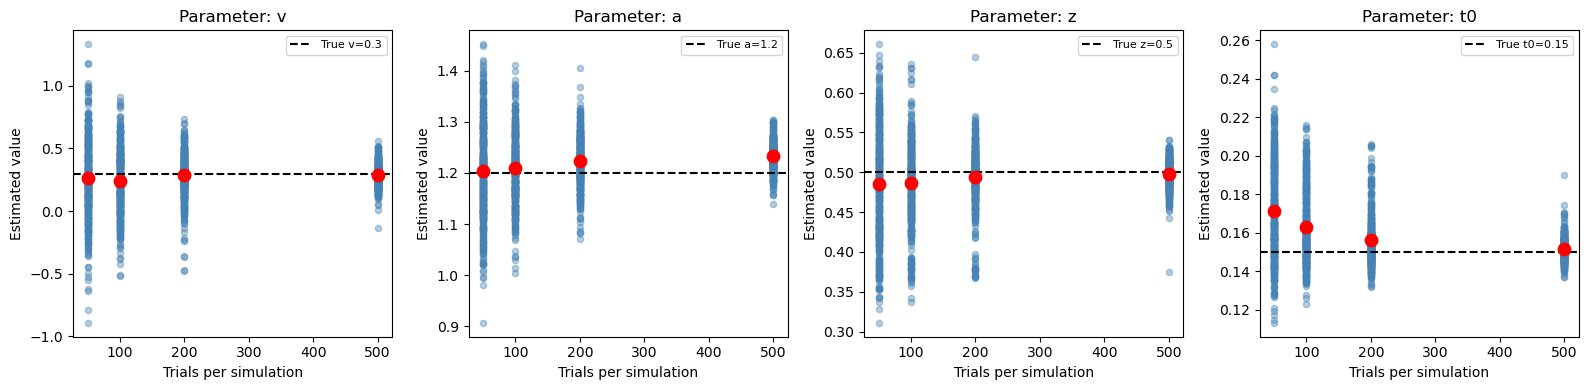

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = ['v', 'a', 'z', 't0']
true_vals = [0.3, 1.2, 0.5, 0.15]

for i, (param, true_val) in enumerate(zip(params, true_vals)):
    ax = axes[i]
    for n in sample_sizes:
        subset = df_500[df_500['n_trials'] == n]
        estimates = subset[f'est_{param}']
        ax.scatter([n] * len(estimates), estimates, 
                  alpha=0.4, s=20, color='steelblue')
        ax.scatter(n, estimates.mean(), 
                  s=80, color='red', zorder=5)
    
    ax.axhline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {param}={true_val}')
    ax.set_xlabel('Trials per simulation')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'Parameter: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('recovery_plot_500.png', dpi=150)
plt.show()

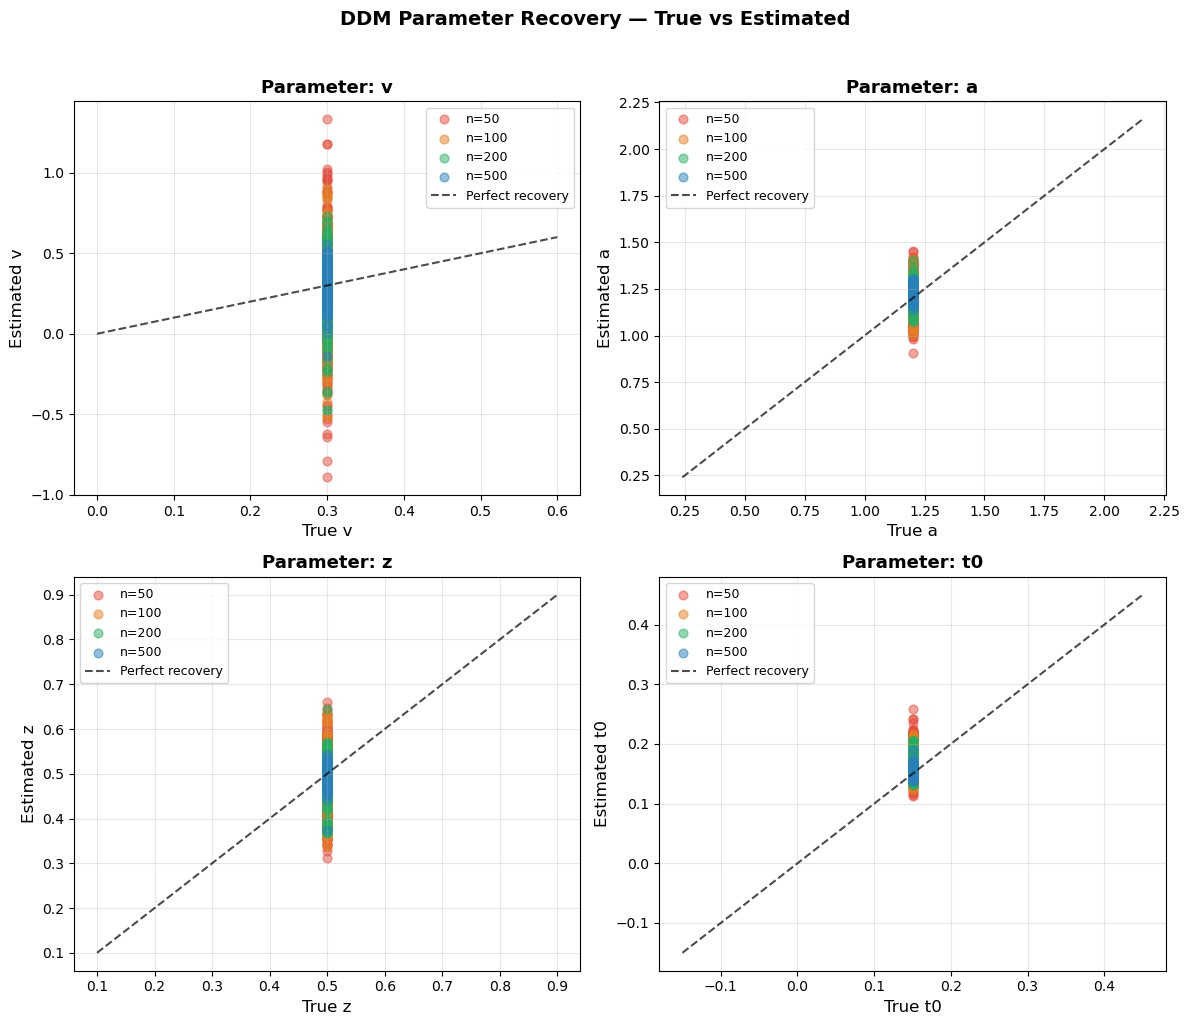

Figure saved as recovery_scatter_500.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
colors = {50: '#e74c3c', 100: '#e67e22', 200: '#27ae60', 500: '#2980b9'}
labels = {50: 'n=50', 100: 'n=100', 200: 'n=200', 500: 'n=500'}

for idx, param in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    for n in [50, 100, 200, 500]:
        subset = df[df['n_trials'] == n]
        ax.scatter(
            subset[f'true_{param}'],
            subset[f'est_{param}'],
            alpha=0.5, s=40,
            color=colors[n],
            label=labels[n]
        )
    
    # Perfect recovery diagonal
    true_val = true_vals[param]
    spread = max(0.3, abs(true_val) * 0.8)
    lims = [true_val - spread, true_val + spread]
    ax.plot(lims, lims, 'k--', linewidth=1.5, 
            alpha=0.7, label='Perfect recovery')
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Estimated {param}', fontsize=12)
    ax.set_title(f'Parameter: {param}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DDM Parameter Recovery — True vs Estimated', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recovery_scatter_500.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recovery_scatter_500.png")